# Query-splitting RAG agent

**The goal** — a user asks a question, and the system finds relevant information from multiple sources (LangGraph docs, LangChain docs, PDF files, and Wikipedia) and returns a concise answer.

---

**Step 1 — Setup (Cell 0)**
Loads all the libraries needed and initialises the GPT-4o language model that will be used throughout.

---

**Step 2 — Building the knowledge bases (Cell 2)**
Defines two helper functions. The first takes a list of website URLs, downloads the text from those pages, cuts it into overlapping chunks, converts each chunk into a vector of numbers (embeddings), and saves everything into a FAISS index on your disk. The second does the same thing but reads from local PDF files instead of websites. Both functions check if the index already exists on disk first — if it does, they skip all the downloading and embedding and just load it directly, which saves money and time on every run after the first.

---

**Step 3 — Building the tools (Cell 3)**
Uses those two functions to actually create three knowledge bases — one for LangGraph docs, one for LangChain docs, and one for your PDF files. Then wraps each into a retriever tool the agent can call. Each retriever tool uses two-stage retrieval: first MMR to get a diverse set of candidate chunks, then relevance score filtering to drop any chunk that scores below a quality threshold. Wikipedia is also added as a fourth tool for fallback. All four tools are collected into a list.

---

**Step 4 — State definition (Cell 4)**
Defines what information gets passed between every step of the pipeline. It tracks three things: the full conversation history, the list of sub-questions the question was split into, and a dictionary mapping each sub-question to whatever content was retrieved for it.

---

**Step 5 — Chains (Cell 5)**
Builds three reusable LLM chains that are constructed once and shared across the whole pipeline. The decompose chain takes a question and breaks it into sub-questions. The generation chain takes retrieved context and a question and produces a final answer. The agent model is the LLM with all four tools attached so it knows what it can call.

---

**Step 6 — The four nodes (Cell 6)**
This is the core logic.

The **decompose node** takes the original question, sends it to the decompose chain, and parses the numbered list output into a clean Python list of sub-questions. Simple questions come back as a single item.

The **agent node** loops over every sub-question and sends each one to the LLM separately. For each sub-question the LLM decides which tool to call and returns a response with a tool call attached.

The **retriever node** is a prebuilt LangGraph component that reads the tool calls the agent produced, actually executes them against the right vectorstore or Wikipedia, and appends the results to the conversation history.

The **generate node** collects all the tool results from the conversation history, maps each result back to the sub-question it came from, builds a structured context block with one labelled section per sub-question, and sends it to the RAG chain to produce the final answer.

---

**Step 7 — Graph wiring (Cell 7)**
Connects the four nodes into a directed graph. Every question always goes through decompose first, then agent, then retriever, then generate, then ends. The only branch is after the agent — if the agent decides it does not need to call any tool, it skips straight to the end without retrieving anything.

---

**Step 8 — Run (Cell 8)**
Invokes the compiled graph with a question, waits for it to finish, and prints the final answer.

In [ ]:
#── Imports ───────────────────────────────────────────────────────────────────
import logging
import os
from typing import Annotated, Literal, Sequence

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

try:
    llm = init_chat_model("openai:gpt-4o")
    logger.info("LLM initialised: gpt-4o")
except Exception as e:
    logger.exception("Failed to initialise LLM.")
    raise

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
2026-02-19 22:09:59,418 [INFO] LLM initialised: gpt-4o


```

So the flow is now:

Agent decides to use tool
        ↓
retrieve_from_vectorstore(query) is called by the agent
        ↓
retriever.invoke(query)  ← MMR handles diversity
        ↓
similarity_search_with_relevance_scores(query) ← gets scores for quality filtering
        ↓
score_lookup filters out low-quality MMR chunks
        ↓
returns formatted string back to agent
```

In [7]:
# =============================================================================
# 1. Vectorstore builder
# =============================================================================

def build_vectorstore_from_urls(
    urls: list[str],
    faiss_index_path: str,
    chunk_size: int = 1000,
    chunk_overlap: int = 100,
    embedding_model: str = "text-embedding-3-small",
    embedding_chunk_size: int = 200,
) -> FAISS:
    """
    Load a FAISS index from disk if it exists, otherwise build one from the
    given URLs and persist it.  Avoids re-embedding on every run.
    """
    embedding = OpenAIEmbeddings(
        model=embedding_model,
        chunk_size=embedding_chunk_size,
    )

    if os.path.exists(faiss_index_path):
        print(f"[VectorStore] Loaded from disk: {faiss_index_path}")
        return FAISS.load_local(
            faiss_index_path,
            embeddings=embedding,
            allow_dangerous_deserialization=True,
        )

    docs = [item for url in urls for item in WebBaseLoader(url).load()]

    doc_splits = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        add_start_index=True,  # stores char offset for traceability
    ).split_documents(docs)

    vectorstore = FAISS.from_documents(documents=doc_splits, embedding=embedding)
    vectorstore.save_local(faiss_index_path)
    print(f"[VectorStore] Built and saved: {faiss_index_path} ({len(doc_splits)} chunks)")
    return vectorstore


# =============================================================================
# 2. Custom retriever tool factory
# =============================================================================

def create_custom_retriever_tool(
    vectorstore: FAISS,
    tool_name: str,
    tool_description: str,
    threshold: float = 0.30,
    k: int = 5,
    fetch_k: int = 20,
    lambda_mult: float = 0.6,
):
    """
    Returns a @tool that:
      1. Uses MMR retrieval for diversity-aware candidate selection.
      2. Scores those candidates via similarity_search_with_relevance_scores.
      3. Filters out any chunk below `threshold` before returning to the agent.
    """
    # MMR retriever — built once, reused on every tool call via closure
    retriever = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": k, "fetch_k": fetch_k, "lambda_mult": lambda_mult},
    )

    @tool(tool_name)
    def retrieve_from_vectorstore(query: str) -> str:
        """Placeholder — overridden by tool_description below."""

        # Step 1: MMR gives us a diverse, relevant candidate set
        mmr_docs = retriever.invoke(query)

        # Step 2: Get relevance scores for the same query (MMR doesn't return scores)
        docs_with_scores = vectorstore.similarity_search_with_relevance_scores(query, k=k)
        score_lookup = {doc.page_content: score for doc, score in docs_with_scores}

        # Step 3: Keep only MMR docs whose similarity score clears the threshold
        filtered = [
            (doc, score_lookup.get(doc.page_content, 0.0))
            for doc in mmr_docs
            if score_lookup.get(doc.page_content, 0.0) >= threshold
        ]

        if not filtered:
            return "No relevant documents found in the local vector store."

        results = [
            f"[Chunk {i}] Score: {score:.2f} | Source: {doc.metadata.get('source', 'Unknown')}\n{doc.page_content}"
            for i, (doc, score) in enumerate(filtered, 1)
        ]
        return "\n\n---\n\n".join(results)

    # Override the docstring so the LLM sees the real description
    retrieve_from_vectorstore.description = tool_description
    return retrieve_from_vectorstore
from langchain_community.document_loaders import PyPDFLoader

def build_vectorstore_from_pdfs(
    pdf_paths: list[str],
    faiss_index_path: str,
    chunk_size: int = 1000,
    chunk_overlap: int = 100,
    embedding_model: str = "text-embedding-3-small",
    embedding_chunk_size: int = 200,
) -> FAISS:
    """
    Load a FAISS index from disk if it exists, otherwise build one from
    local PDF files and persist it for future runs.

    Args:
        pdf_paths:            Absolute or relative paths to local PDF files.
        faiss_index_path:     Directory path for the FAISS index on disk.
        chunk_size:           Character size of each document chunk.
        chunk_overlap:        Overlap between consecutive chunks.
        embedding_model:      OpenAI embedding model name.
        embedding_chunk_size: Batch size for the embedding API calls.

    Returns:
        A FAISS vectorstore instance ready for retrieval.

    Raises:
        ValueError:   If faiss_index_path is empty or no valid PDFs found.
        RuntimeError: If documents cannot be loaded, split, or embedded.
    """
    if not faiss_index_path:
        raise ValueError("faiss_index_path must not be empty.")

    embedding = OpenAIEmbeddings(
        model=embedding_model,
        chunk_size=embedding_chunk_size,
    )

    # ── Load from disk (cache hit) ────────────────────────────────────────────
    if os.path.exists(faiss_index_path):
        try:
            vs = FAISS.load_local(
                faiss_index_path,
                embeddings=embedding,
                allow_dangerous_deserialization=True,
            )
            logger.info("VectorStore loaded from disk: %s", faiss_index_path)
            return vs
        except Exception as e:
            logger.warning(
                "Corrupt FAISS index at %s (%s) — rebuilding...", faiss_index_path, e
            )

    # ── Build from PDFs (cache miss) ──────────────────────────────────────────
    if not pdf_paths:
        raise ValueError(
            f"No FAISS index found at '{faiss_index_path}' and no PDF paths provided."
        )

    # Validate paths before loading
    missing = [p for p in pdf_paths if not os.path.exists(p)]
    if missing:
        raise ValueError(f"PDF file(s) not found: {missing}")

    logger.info("Loading %d PDF file(s)...", len(pdf_paths))
    docs = []
    for path in pdf_paths:
        try:
            loaded = PyPDFLoader(path).load()
            docs.extend(loaded)
            logger.info("Loaded %d page(s) from: %s", len(loaded), path)
        except Exception as e:
            logger.error("Failed to load PDF '%s': %s — skipping.", path, e)

    if not docs:
        raise RuntimeError("No documents were loaded from the provided PDF files.")

    doc_splits = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        add_start_index=True,
    ).split_documents(docs)

    if not doc_splits:
        raise RuntimeError("Text splitter produced zero chunks from the PDF files.")

    try:
        vectorstore = FAISS.from_documents(documents=doc_splits, embedding=embedding)
        vectorstore.save_local(faiss_index_path)
    except Exception as e:
        raise RuntimeError(f"Failed to build or save FAISS index: {e}") from e

    logger.info(
        "VectorStore built and saved: %s (%d chunks)", faiss_index_path, len(doc_splits)
    )
    return vectorstore

In [8]:
langgraph_vs = build_vectorstore_from_urls([
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
    ],
    faiss_index_path="langgraph_blog_faiss_index"
)

langchain_vs = build_vectorstore_from_urls([
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
    ],
    faiss_index_path="langchain_blog_faiss_index"
)

pdf_vs = build_vectorstore_from_pdfs(
     pdf_paths=[
         "./pdf/Earnings-Presentation-Q3-2025-Final.pdf",   # ← user fills in real paths
         "./pdf/ICIBM 2025_submission_43_paper_v2.pdf",
     ],
     faiss_index_path="pdf_faiss_index",
 )

retriever_tool = create_custom_retriever_tool(
    langgraph_vs,
    tool_name="retriever_vector_db_blog",
    tool_description="Search and return information about Langgraph",
    threshold=0.30
)

retriever_tool_langchain = create_custom_retriever_tool(
    langchain_vs,
    tool_name="retriever_vector_langchain_blog",
    tool_description="Search and return information about Langchain",
    threshold=0.35,  # you can tune per tool,
    lambda_mult=0.7, # tune per tool as needed based on relevance vs diversity tradeoff
)
retriever_tool_pdf = create_custom_retriever_tool(
    pdf_vs,
    tool_name="retriever_pdf_documents",
    tool_description=(
         "Search and retrieve information from locally stored PDF documents. "
         "Use this tool when the question is about content from uploaded PDF files."
     ),
    threshold=0.30,
    lambda_mult=0.7, # tune per tool as needed based on relevance vs diversity tradeoff
 )

# Wikipedia tool — used as fallback when local docs are insufficient
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=3,        # return top 3 Wikipedia articles
        doc_content_chars_max=2000,  # cap each article at 2000 chars
    )
)

tools = [retriever_tool, retriever_tool_langchain, wikipedia_tool, retriever_tool_pdf]

2026-02-19 22:10:27,058 [INFO] Loading faiss with AVX2 support.
2026-02-19 22:10:27,073 [INFO] Successfully loaded faiss with AVX2 support.


[VectorStore] Loaded from disk: langgraph_blog_faiss_index
[VectorStore] Loaded from disk: langchain_blog_faiss_index


2026-02-19 22:10:27,712 [INFO] VectorStore loaded from disk: pdf_faiss_index


In [9]:
# =============================================================================
# 4. LangGraph State
# =============================================================================
from typing import List
class AgentState(TypedDict):
    """
    State passed between nodes in the LangGraph workflow.

    messages:      full conversation history (merged by add_messages reducer).
    rewrite_count: tracks how many times we've rewritten the query — used
                   to break out of loops when retrieval keeps failing.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    rewrite_count: int
    sub_questions: List[str]  # populated by decompose_query tool


MAX_REWRITES = 3  # safety ceiling — prevents infinite rewrite → agent loops

In [10]:
# =============================================================================
# 2. Shared chains
# =============================================================================

# ── Decompose chain ───────────────────────────────────────────────────────────
_decompose_prompt = ChatPromptTemplate.from_messages([
    (
        "human",
        "You are a question decomposition assistant."
        "Break the following question into at most 5 smaller, self-contained "
        "sub-questions that together cover the full intent of the original."
        "Rules:"
        "- If the question is already simple, return it as a single item."
        "- Each sub-question must be independently answerable."
        "- Return ONLY a numbered list, one sub-question per line, no extra text."
        "Question: {question}"
    )
])
_decompose_chain = _decompose_prompt | llm | StrOutputParser()


# ── RAG generation chain ──────────────────────────────────────────────────────
_generate_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant for question-answering tasks."
        "Use the retrieved context below to answer the question."
        "Context is organised by sub-question — use all of it."
        "If a sub-question has no context, acknowledge the gap rather than guessing."
        "Keep the answer concise (five sentences maximum)."
        "Context: {context}",
    ),
    ("human", "{question}"),
])
_rag_chain = _generate_prompt | llm | StrOutputParser()


# ── Agent model — tools bound once ────────────────────────────────────────────
_agent_model = llm.bind_tools(tools)


In [11]:
# =============================================================================
# 3. Graph Nodes
# =============================================================================

# ── Node 1: decompose ─────────────────────────────────────────────────────────
def decompose(state: AgentState) -> dict:
    """
    Split the original question into smaller sub-questions.
    Falls back to the original question if parsing fails.
    """
    logger.info("---DECOMPOSE---")
    question = state["messages"][0].content

    try:
        raw = _decompose_chain.invoke({"question": question})
    except Exception as e:
        logger.error("Decompose failed: %s — using original question.", e)
        raw = f"1. {question}"

    # Parse "1. question 2. question..." into a clean list
    sub_questions: list[str] = []
    for line in raw.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        # Strip leading markers: "1." / "1)" / "-"
        for sep in (". ", ") ", "- "):
            if len(line) > 2 and line[1:3] == sep[:2]:
                line = line[3:].strip()
                break
        if line:
            sub_questions.append(line)

    if not sub_questions:
        logger.warning("Decompose produced nothing — using original question.")
        sub_questions = [question]

    logger.info("Decomposed into %d sub-question(s): %s", len(sub_questions), sub_questions)

    return {
        "sub_questions":  sub_questions,
        "retrieved_docs": {},   # initialise accumulator
    }


# ── Node 2: agent ─────────────────────────────────────────────────────────────
def agent(state: AgentState) -> dict:
    """
    Invoke the LLM with bound tools for each sub-question independently.
    Each sub-question gets its own call so tool selection stays focused.
    """
    logger.info("---CALL AGENT---")
    sub_questions = state.get("sub_questions", [])

    if not sub_questions:
        logger.warning("Agent called with no sub-questions.")
        return {"messages": []}

    responses = []
    for sub_q in sub_questions:
        try:
            response = _agent_model.invoke([HumanMessage(content=sub_q)])
            responses.append(response)
            logger.info("Agent processed: '%s'", sub_q)
        except Exception as e:
            logger.error("Agent failed for '%s': %s", sub_q, e)
            responses.append(HumanMessage(content=f"[ERROR] Could not process: {sub_q}"))

    return {"messages": responses}


# ── Node 3: retriever (prebuilt ToolNode) ─────────────────────────────────────
# Reads tool_calls from the latest AIMessage, executes the tool,
# and appends a ToolMessage with the result. No custom logic needed.
_tool_node = ToolNode(tools)


# ── Node 4: generate ──────────────────────────────────────────────────────────
def generate(state: AgentState) -> dict:
    """
    Collect all ToolMessage results, map them back to sub-questions,
    and produce a final answer.
    """
    logger.info("---GENERATE---")

    original_question: str       = state["messages"][0].content
    sub_questions:     list[str] = state.get("sub_questions", [])
    retrieved_docs:    dict      = dict(state.get("retrieved_docs", {}))

    # Extract ToolMessages from conversation history and map to sub-questions
    messages   = list(state["messages"])
    tool_msgs  = [m for m in messages if getattr(m, "type", None) == "tool"]

    no_result = "No relevant documents found in the local vector store."
    for i, sub_q in enumerate(sub_questions):
        if i < len(tool_msgs):
            content = tool_msgs[i].content.strip()
            if content and content != no_result:
                retrieved_docs[sub_q] = content
        if sub_q not in retrieved_docs:
            retrieved_docs[sub_q] = ""  # mark as attempted but empty

    # Build structured context: one labelled section per sub-question
    sections = []
    for i, sub_q in enumerate(sub_questions, 1):
        content = retrieved_docs.get(sub_q, "")
        if content:
            sections.append(
                f"Sub-question {i}: {sub_q} Retrieved context:"
                # f"Sub-question {i}: {sub_q} Retrieved context: {content}" --- IGNORE ---
                )
        else:
            sections.append(
                f"Sub-question {i}: {sub_q} Retrieved context: [No relevant documents found]"
            )

    context = ("" + "─" * 60 + "\n").join(sections)

    try:
        response = _rag_chain.invoke({
            "context":  context,
            "question": original_question,
        })
    except Exception as e:
        logger.error("RAG chain failed: %s", e)
        response = "An error occurred while generating the answer. Please try again."

    logger.info("Generation complete.")
    return {
        "messages":       [response],
        "retrieved_docs": retrieved_docs,
    }



[Graph] Compiled successfully.


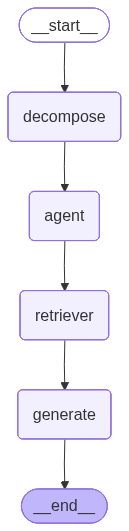

In [14]:
# =============================================================================
# 4. Build the LangGraph Workflow
# =============================================================================
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

builder = StateGraph(AgentState)

# Register nodes
builder.add_node("decompose", decompose)
builder.add_node("agent",     agent)
builder.add_node("retriever", _tool_node)
builder.add_node("generate",  generate)

# ── Edges ─────────────────────────────────────────────────────────────────────

# Always decompose the question first
builder.add_edge(START, "decompose")

# After decompose, always go to agent
builder.add_edge("decompose", "agent")

# Agent decides: call a tool (retrieve) or end directly
builder.add_edge("agent", "retriever")

# After retrieval, always generate — no grading step
builder.add_edge("retriever", "generate")

# After generate, done
builder.add_edge("generate", END)

graph = builder.compile()
print("[Graph] Compiled successfully.")

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [13]:
result = graph.invoke({
    "messages":       [HumanMessage(content="What is LangGraph and how does it differ from LangChain?")],
    "sub_questions":  [],
    "retrieved_docs": {},
})

print(result["messages"][-1])

2026-02-19 22:10:31,947 [INFO] ---DECOMPOSE---
2026-02-19 22:10:32,916 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-19 22:10:32,936 [INFO] Decomposed into 5 sub-question(s): ['What is LangGraph?', 'What is LangChain?', 'What are the key features of LangGraph?', 'What are the key features of LangChain?', 'How do the features of LangGraph differ from those of LangChain?']
2026-02-19 22:10:32,937 [INFO] ---CALL AGENT---
2026-02-19 22:10:33,662 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-19 22:10:33,669 [INFO] Agent processed: 'What is LangGraph?'
2026-02-19 22:10:35,227 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-19 22:10:35,232 [INFO] Agent processed: 'What is LangChain?'
2026-02-19 22:10:35,882 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-19 22:10:35,886 [INFO] Agent processed: 'What are 

content="I'm sorry, but I don't have information about LangGraph. Similarly, I do not have information on LangChain or how they might differ. If you have specific details or context about these topics, I'd be happy to help further within that scope." additional_kwargs={} response_metadata={} id='89138f89-104d-4919-bf01-6791a75071bc'
